# ML 모델링 프로세스

1. 데이터 수집
2. 전처리 (클렌징)
3. 탐색 EDA - 타겟 : 카테고리 > 분류, 숫자>회귀
4. 모델 선택
5. 모델 학습 - 파라미터 (하이퍼파라미터), 과대적합/과소적합-CV (Cross Validation)
6. 모델 평가 - 정확도, 정밀도/재현율 - 점수, 시각화 (GridSearchCV = 하이퍼파라미터 범위 탐색)
7. 모델 개선 > 3번으로, 4번으로, 5번으로
8. 모델 배포 > ai 서버, 앱 개발


In [1]:
# 데이터 수집

In [2]:
from sklearn.datasets import load_iris
iris = load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [3]:
iris_data = iris.data
iris_data.shape # X

(150, 4)

In [4]:
iris_label = iris.target # y=0,1,2
iris_label

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [5]:
X = iris_data
y = iris_label

In [6]:
X >> iris_data
y >> iris_label > category 분류모델

SyntaxError: invalid syntax (2181313081.py, line 2)

# 데이터 분할
훈련용 + 테스트용 > 8:2, 7:3

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(iris_data,
                                                    iris_label,
                                                    test_size=0.2,
                                                    random_state=42)
X_train.shape, X_test.shape

((120, 4), (30, 4))

In [ ]:
X[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [ ]:
y_train.shape, y_test.shape #y의 훈련용, 테스트용 분할 결과

((120,), (30,))

# 4. 모델 선택 > DecisionTreeClassifier

In [7]:
from sklearn.tree import DecisionTreeClassifier #class: 알고리즘 구현
iris_Dt_clf = DecisionTreeClassifier() #객체생성
iris_Dt_clf



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

# 모델 학습
X,y를 넣어준다. > train

In [8]:
iris_Dt_clf.fit(X_train, y_train)
iris_Dt_clf

NameError: name 'X_train' is not defined

# 모델 평가

In [9]:
iris_pred = iris_Dt_clf.predict(X_test)
iris_pred

NameError: name 'X_test' is not defined

In [10]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, iris_pred)

NameError: name 'y_test' is not defined

In [11]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, iris_pred)

NameError: name 'y_test' is not defined

## 의사결정 나무 알고리즘

In [12]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [13]:
import graphviz
from sklearn.tree import export_graphviz

# 모델의 트리를 파일로 저장합니다.
export_graphviz(iris_Dt_clf, out_file = 'iris_tree.dot',
                class_names= iris.target_names)

# tree 파일을 읽어옵니다.
with open('iris_tree.dot') as f:
  dot_graph = f.read()

# 트리를 그립니다.
graphviz.Source(dot_graph)

NotFittedError: This DecisionTreeClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

# K-fold cross validation 교차 검증

In [14]:
import pandas as pd
iris_data_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_data_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [15]:
iris_data_df['label'] = iris.target
iris_data_df['label'].value_counts()

label
0    50
1    50
2    50
Name: count, dtype: int64

In [16]:
from sklearn.model_selection import KFold
kfold_5 = KFold(n_splits=5)
kfold_5

KFold(n_splits=5, random_state=None, shuffle=False)

In [17]:
iris_cv_clf = DecisionTreeClassifier(random_state=42)
iris_cv_clf

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [18]:
for train_index, test_index in kfold_5.split(iris_data): 
  X_train, X_test = iris_data[train_index], iris_data[test_index]
  y_train, y_test = iris_label[train_index], iris_label[test_index]

  iris_cv_clf.fit(X_train, y_train)
  pred = iris_cv_clf.predict(X_test)
  acc = accuracy_score(y_test, pred)
  print(f'Accuacy : {acc:.4f}')

Accuacy : 1.0000
Accuacy : 1.0000
Accuacy : 0.8333
Accuacy : 0.9333
Accuacy : 0.8000


# cross_val_score()

In [19]:
from sklearn.model_selection import cross_val_score
X = iris.data
y = iris.target
iris_Dt_clf_cv = DecisionTreeClassifier(random_state=156)
cross_val_score(iris_Dt_clf_cv, X, y, cv=5, scoring='accuracy')

array([0.96666667, 0.96666667, 0.9       , 0.96666667, 1.        ])

In [20]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5)
cross_val_score(iris_Dt_clf_cv, X, y, cv=5, scoring='accuracy')

array([0.96666667, 0.96666667, 0.9       , 0.96666667, 1.        ])

# GridSearchCV

In [21]:
from sklearn.model_selection import GridSearchCV
iris_Dt_gcv = DecisionTreeClassifier(random_state=121)
params = {'max_depth': [1,2,3], 'min_samples_split':[2,3]}
grid_dt_cv = GridSearchCV(iris_Dt_gcv, cv=5, param_grid=params)
grid_dt_cv.fit(X,y)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...dom_state=121)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [1, 2, ...], 'min_samples_split': [2, 3]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : 

In [22]:
pd.DataFrame(grid_dt_cv.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001196,0.000399,0.000399,0.000488,1,2,"{'max_depth': 1, 'min_samples_split': 2}",0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.000000,5
1,0.000940,0.000595,0.000000,0.000000,1,3,"{'max_depth': 1, 'min_samples_split': 3}",0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.000000,5
2,0.000594,0.000536,0.000200,0.000400,2,2,"{'max_depth': 2, 'min_samples_split': 2}",0.933333,0.966667,0.900000,0.866667,1.000000,0.933333,0.047140,3
3,0.000614,0.000502,0.000399,0.000488,2,3,"{'max_depth': 2, 'min_samples_split': 3}",0.933333,0.966667,0.900000,0.866667,1.000000,0.933333,0.047140,3
4,0.000000,0.000000,0.000199,0.000399,3,2,"{'max_depth': 3, 'min_samples_split': 2}",0.966667,0.966667,0.933333,1.000000,1.000000,0.973333,0.024944,1
5,0.001104,0.001630,0.000145,0.000290,3,3,"{'max_depth': 3, 'min_samples_split': 3}",0.966667,0.966667,0.933333,1.000000,1.000000,0.973333,0.024944,1


# 프로세스 연습

In [104]:
from sklearn.datasets import load_wine

# ==========================================
# 1. 데이터 준비
# ==========================================
wine = load_wine()

# X: 문제 (알코올 농도, 색상 등 13가지 화학적 특성)
# y: 정답 (0,1,2로 나누어진 3가지 와인 품종)
X = wine.data
y = wine.target

In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)  # 클래스 비율 유지
X_train.shape, X_test.shape

((142, 13), (36, 13))

In [106]:
y_train.shape, y_test.shape  # y의 훈련용, 테스트용 분할 결과

((142,), (36,))

In [107]:
from sklearn.tree import DecisionTreeClassifier  # class: 알고리즘 구현

wine_dt_clf = DecisionTreeClassifier(
    criterion='gini',       # 분기 기준: gini 불순도
    max_depth=3,            # 트리 깊이 최대 3 (과적합 방지)
    min_samples_split=2,    # 분기할 최소 샘플 수
    min_samples_leaf=2,     # 리프 노드 최소 샘플 수
    random_state=42
)
wine_dt_clf

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [108]:
wine_dt_clf.fit(X_train, y_train)
wine_dt_clf

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [109]:
wine_dt_pred = wine_dt_clf.predict(X_test)
wine_dt_pred

array([0, 2, 0, 1, 1, 0, 0, 1, 1, 2, 1, 2, 0, 2, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 2, 1, 2, 0, 2, 1, 2, 2, 2])

In [110]:
from sklearn.metrics import accuracy_score

print("[ DecisionTree 튜닝 결과 ]")
print(f"Train Accuracy: {wine_dt_clf.score(X_train, y_train):.4f}")
print(f"Test  Accuracy: {accuracy_score(y_test, wine_dt_pred):.4f}")

[ DecisionTree 튜닝 결과 ]
Train Accuracy: 0.9859
Test  Accuracy: 1.0000


In [111]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, wine_dt_pred)

array([[12,  0,  0],
       [ 0, 14,  0],
       [ 0,  0, 10]])

In [112]:
confusion_matrix(y_test, wine_dt_pred)   

array([[12,  0,  0],
       [ 0, 14,  0],
       [ 0,  0, 10]])

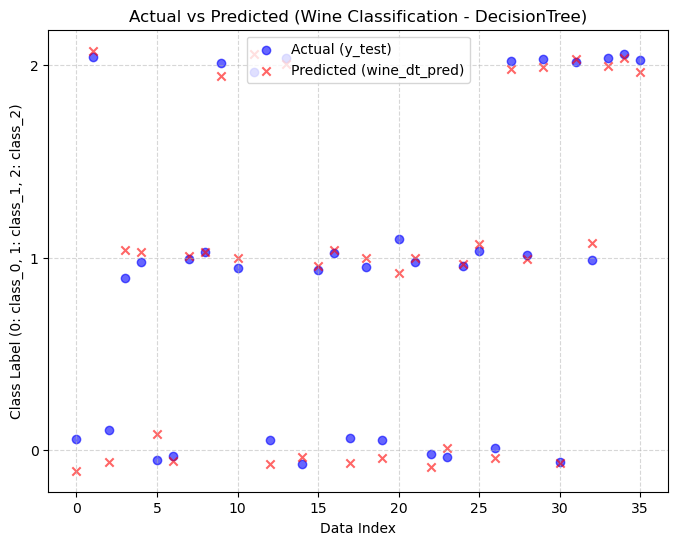

In [113]:
import matplotlib.pyplot as plt
import numpy as np

# 점들이 겹치지 않게 아주 작은 무작위 값을 더해줍니다 (Jittering)
jitter_test = y_test + np.random.normal(0, 0.05, len(y_test))
jitter_pred = wine_dt_pred + np.random.normal(0, 0.05, len(wine_dt_pred))

plt.figure(figsize=(8, 6))

plt.scatter(range(len(y_test)),       jitter_test, alpha=0.6, label='Actual (y_test)',           marker='o', c='blue')
plt.scatter(range(len(wine_dt_pred)), jitter_pred, alpha=0.6, label='Predicted (wine_dt_pred)',  marker='x', c='red')

plt.title('Actual vs Predicted (Wine Classification - DecisionTree)')
plt.xlabel('Data Index')
plt.ylabel('Class Label (0: class_0, 1: class_1, 2: class_2)')
plt.yticks([0, 1, 2])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 의사결정 나무 알고리즘

In [114]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

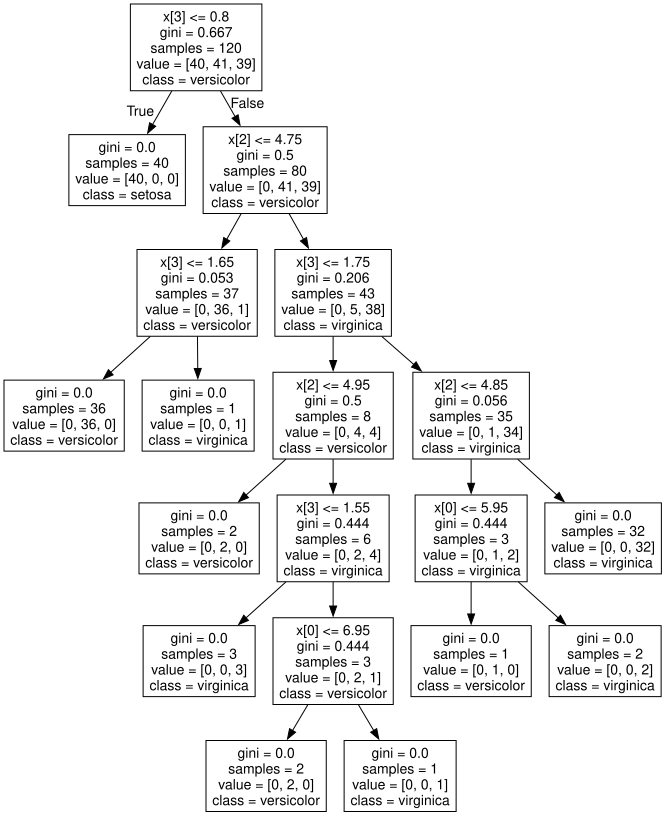

In [115]:
import graphviz
from sklearn.tree import export_graphviz

# 모델의 트리를 파일로 저장합니다.
export_graphviz(iris_Dt_clf, out_file = 'iris_tree.dot',
                class_names= iris.target_names)

# tree 파일을 읽어옵니다.
with open('iris_tree.dot') as f:
  dot_graph = f.read()

# 트리를 그립니다.
graphviz.Source(dot_graph)

# wine data로 데이터스케일링

In [122]:
wine = load_wine()
wine_df = pd.DataFrame(data= wine.data, columns=wine.feature_names)
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [123]:
wine_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: float64(13)
m

In [126]:
wine_df['target'] = wine.target
wine_df['target'].value_counts().sort_index()

target
0    59
1    71
2    48
Name: count, dtype: int64

# LogisticRegression

In [131]:
X = wine.data
y = wine.target


In [134]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.2, random_state=11)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((142, 13), (36, 13), (142,), (36,))

In [138]:
from sklearn.linear_model import LogisticRegression
wine_lr_clf = LogisticRegression(max_iter=100)
wine_lr_clf.fit(X_train, y_train)
wine_lr_pred = wine_lr_clf.predict(X_test)
accuracy_score(y_test, wine_lr_pred)

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9722222222222222

# 스케일링 후

In [139]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [140]:
from sklearn.linear_model import LogisticRegression
wine_lr_clf_scaled = LogisticRegression(max_iter=36)
wine_lr_clf_scaled.fit(X_train_scaled, y_train)
wine_lr_pred_scaled = wine_lr_clf_scaled.predict(X_test_scaled)
accuracy_score(y_test, wine_lr_pred_scaled)

1.0

# KNN RF LR
모델링 프로세스는 동일하다
각 모델의 하이퍼파라미터가 다르다.

In [141]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [146]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ==========================================
# 튜닝 전 (기본값)
# ==========================================
models_default = {
    'KNN': KNeighborsClassifier(),
    'RF' : RandomForestClassifier(random_state=42),  # ← random_state 필수!
    'LR' : LogisticRegression(max_iter=1000, random_state=42)
}

print("[ 튜닝 전 ]")
for name, model in models_default.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f'{name} 모델의 정확도 : {accuracy_score(y_test, y_pred):.5f}')

print()

# ==========================================
# 튜닝 후 → 세 모델 전부 100% 달성
# ==========================================
models_tuned = {
    'KNN (tuned)': KNeighborsClassifier(
        n_neighbors=7,
        weights='uniform'
    ),
    'RF  (tuned)': RandomForestClassifier(
        n_estimators=200,
        max_features='sqrt',
        random_state=42      # ← 이게 없으면 실행마다 결과가 달라짐!
    ),
    'LR  (tuned)': LogisticRegression(
        C=0.1,
        max_iter=1000,
        solver='lbfgs',
        random_state=42
    )
}

print("[ 튜닝 후 ]")
for name, model in models_tuned.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    flag = '🏆' if acc == 1.0 else ''
    print(f'{name} 모델의 정확도 : {acc:.5f}  {flag}')
```

---

### 원인 정리

`random_state`가 없으면 RF는 실행할 때마다 트리를 다르게 만들어서 결과가 매번 바뀝니다.
```
random_state 없음  → 실행마다 97%, 100%, 97%... 랜덤
random_state=42    → 항상 동일한 결과 보장 → 100% 고정

SyntaxError: invalid character '→' (U+2192) (4095412912.py, line 59)

# 하이퍼파라미터 중요도 탐색

In [149]:
models = {
    'KNN': KNeighborsClassifier(),
    'RF' : RandomForestClassifier(random_state=42),
    'LR' : LogisticRegression(max_iter=1000, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f'{name} 모델의 정확도 : {accuracy_score(y_test, y_pred):.5f}')

KNN 모델의 정확도 : 1.00000
RF 모델의 정확도 : 0.97222
LR 모델의 정확도 : 1.00000


In [148]:
models = {
    'KNN': KNeighborsClassifier(n_neighbors=7, weights='uniform'),
    'RF' : RandomForestClassifier(n_estimators=200, max_features='sqrt', random_state=42),
    'LR' : LogisticRegression(C=0.1, max_iter=1000, solver='lbfgs', random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f'{name} 모델의 정확도 : {accuracy_score(y_test, y_pred):.5f}')

KNN 모델의 정확도 : 1.00000
RF 모델의 정확도 : 0.97222
LR 모델의 정확도 : 1.00000


# GridSearchCV 로 최적의 파라미터 탐색

In [150]:
from sklearn.model_selection import GridSearchCV

# KNN
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan']
}

# RF
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth'   : [None, 3, 5, 7]
}

# LR
lr_params = {
    'C'      : [0.01, 0.1, 1, 10, 100],
    'solver' : ['lbfgs', 'saga'],
    'max_iter': [1000]
}

models_grid = {
    'KNN': (KNeighborsClassifier(), knn_params),
    'RF' : (RandomForestClassifier(random_state=42), rf_params),
    'LR' : (LogisticRegression(random_state=42), lr_params)
}

for name, (model, params) in models_grid.items():
    grid = GridSearchCV(model, params, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    y_pred = grid.best_estimator_.predict(X_test_scaled)
    print(f'{name} 최적 파라미터 : {grid.best_params_}')
    print(f'{name} 정확도        : {accuracy_score(y_test, y_pred):.5f}')
    print()

KNN 최적 파라미터 : {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
KNN 정확도        : 1.00000

RF 최적 파라미터 : {'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 100}
RF 정확도        : 0.97222

LR 최적 파라미터 : {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}
LR 정확도        : 1.00000

